In [8]:
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
from scipy.ndimage import gaussian_filter
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split

import sequencer

fits_file = "combined_cube.fits"

DPI = 200

print("Loading data...")

with fits.open(fits_file) as hdul:
    data = hdul[0].data
    wcs = WCS(hdul[0].header)
    print("Data loaded.")

# output_dir = "original"
# os.makedirs(output_dir, exist_ok=True)

n_slices = data.shape[0]
cols = data .shape[1]
rows = data.shape[2]

print("Number of slices: ", n_slices)
print("Number of rows: ", rows)
print("Number of columns: ", cols)
print("Number of pixel:", rows*cols)

Loading data...
Data loaded.
Number of slices:  19
Number of rows:  310
Number of columns:  250
Number of pixel: 77500


In [9]:
# flatten the data array
data_2d = data.reshape(data.shape[0],-1)
data_2d.shape

(19, 77500)

Text(0, 0.5, 'object index')

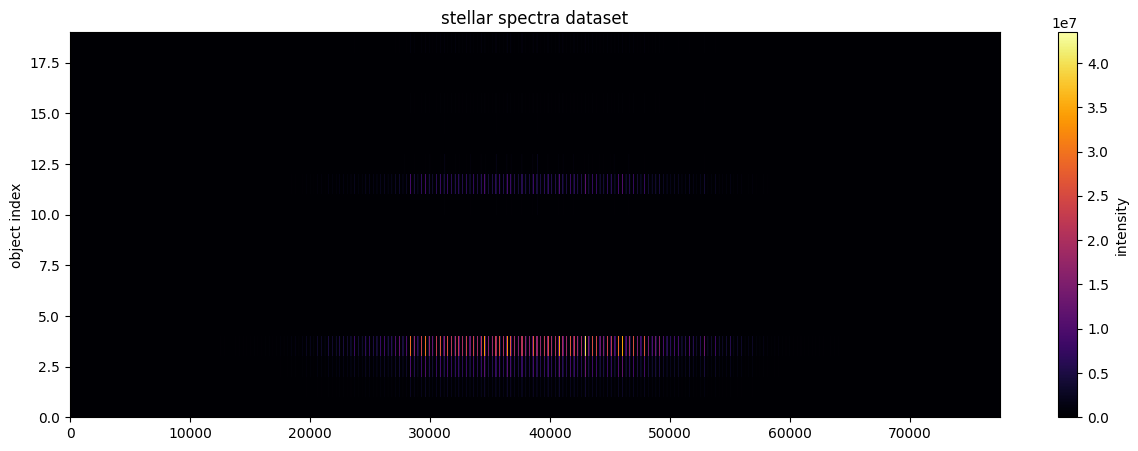

In [10]:
plt.figure(2, figsize=(15, 5))
plt.title("stellar spectra dataset")
plt.pcolormesh(data_2d, cmap="inferno")
plt.colorbar(label="intensity")
plt.ylabel("x")
plt.ylabel("object index")


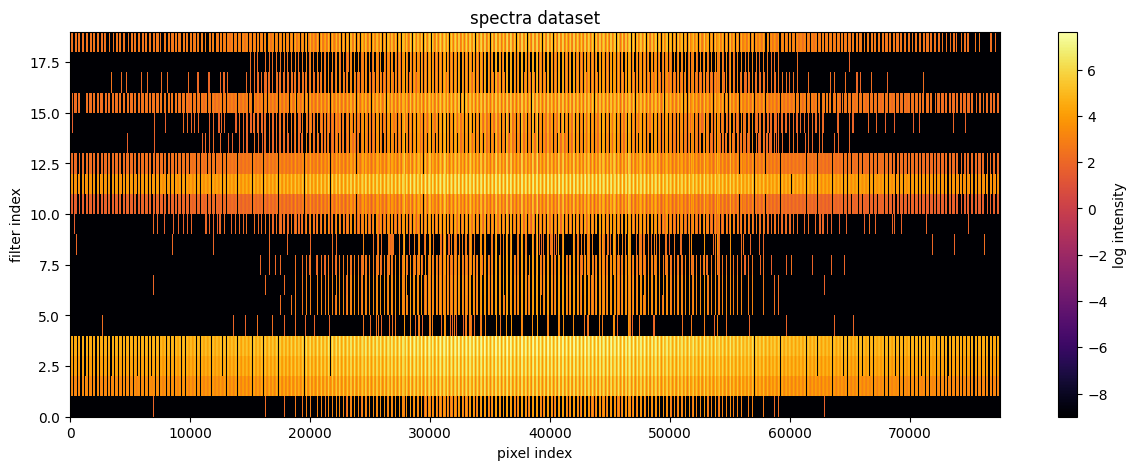

In [17]:
from matplotlib.pyplot import step
log_data = np.log10(data_2d+10e-10)

plt.figure(2, figsize=(15, 5))
plt.title("spectra dataset")
plt.pcolormesh(log_data, cmap="inferno")
plt.colorbar(label="log intensity")
plt.xlabel("pixel index")
plt.ylabel("filter index")

#plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()

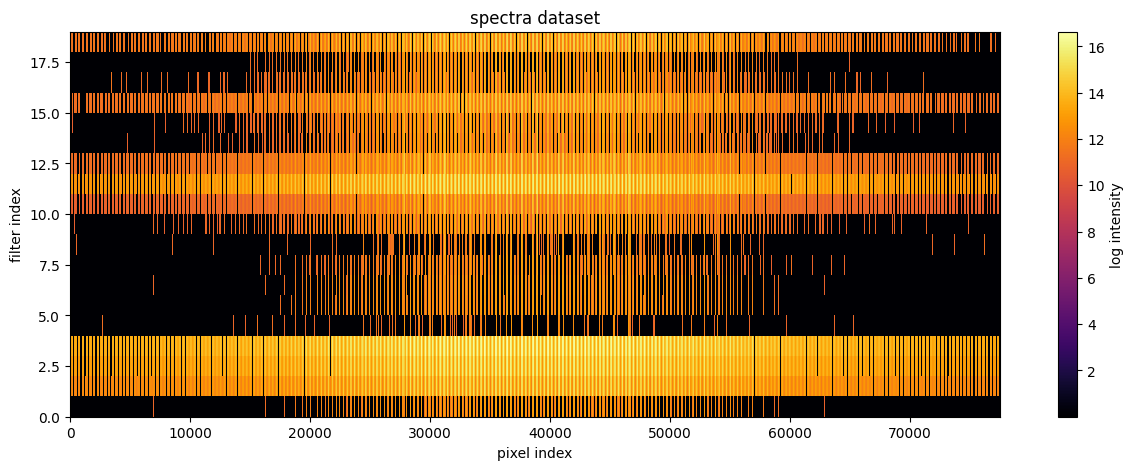

In [16]:
# Add an offset to ensure all values are strictly positive, as required by Sequencer
min_val = np.min(log_data)
if min_val <= 0:
    positive_data = log_data - min_val + 1e-5


plt.figure(2, figsize=(15, 5))
plt.title("spectra dataset")
plt.pcolormesh(positive_data, cmap="inferno")
plt.colorbar(label="log intensity")
plt.xlabel("pixel index")
plt.ylabel("filter index")

#plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()

In [13]:
# Create a simple uniform grid for the feature dimension
grid = np.arange(positive_data.shape[1])
# Define the scales to evaluate
sub_scale_list = [1,2,5,10,15,100]

# Define distance metrics to evaluate
estimator_list = ['EMD']#, 'energy', 'L2', 'KL']

scale_list = [sub_scale_list] * len(estimator_list)

num_of_models = len(estimator_list) * len(sub_scale_list)
num_estimators = int(np.sqrt(num_of_models))    

print("Number of models: ", num_of_models)
print("Number of estimators: ", num_estimators)

seq_out_dir = "sequencer_output"
os.makedirs(seq_out_dir, exist_ok=True)
# Instantiate the Sequencer
seq = sequencer.Sequencer(grid, positive_data, estimator_list, scale_list=None) 
# if scale_list=None then it will use scales of power of 2, until a minimum of 20 pixels per group

Number of models:  6
Number of estimators:  2


In [14]:
final_elongation, final_sequence = seq.execute(seq_out_dir, to_average_N_best_estimators=True, 
                                                number_of_best_estimators=num_estimators,
                                                #to_calculate_distance_matrices=False,
                                                #distance_matrices_inpath= seq_out_dir + "/distance_matrices.pkl",
                                                to_use_parallelization=True,
                                                num_cores=2)

print("Sequencer completed.")
print("Final Elongation:", final_elongation)

Parallelization is ON. Number of cores: 2
calculating the distance matrices for estimator: EMD, scale: 1
finished calculating this distance matrix list, it took: 2.317192792892456 seconds
calculating the distance matrices for estimator: EMD, scale: 2
finished calculating this distance matrix list, it took: 0.5762701034545898 seconds
calculating the distance matrices for estimator: EMD, scale: 4
finished calculating this distance matrix list, it took: 0.4290330410003662 seconds
calculating the distance matrices for estimator: EMD, scale: 8
finished calculating this distance matrix list, it took: 0.3714931011199951 seconds
calculating the distance matrices for estimator: EMD, scale: 16
finished calculating this distance matrix list, it took: 0.5032174587249756 seconds
calculating the distance matrices for estimator: EMD, scale: 32
finished calculating this distance matrix list, it took: 0.7557282447814941 seconds
calculating the distance matrices for estimator: EMD, scale: 64
finished ca

/home/dp/Documents/GitHub/sequencer_project/.venv/lib/python3.13/site-packages/sequencer/sequencer_.py:1040: RuntimeWarning: divide by zero encountered in divide
  distance_matrix = 1.0 / proximity_matrix_copy


resulting elongation:  14.296398891966758
intermediate elongations for the different metrics and scales:
metric=EMD, scale=1, elongation: 17.75
metric=EMD, scale=2, elongation: 17.75
metric=EMD, scale=4, elongation: 17.85
metric=EMD, scale=8, elongation: 12.8
metric=EMD, scale=16, elongation: 9.71
metric=EMD, scale=32, elongation: 9.04
metric=EMD, scale=64, elongation: 8.91
metric=EMD, scale=128, elongation: 10.07
metric=EMD, scale=256, elongation: 10.15
metric=EMD, scale=512, elongation: 11.24
metric=EMD, scale=1024, elongation: 10.65
metric=EMD, scale=2048, elongation: 7.95


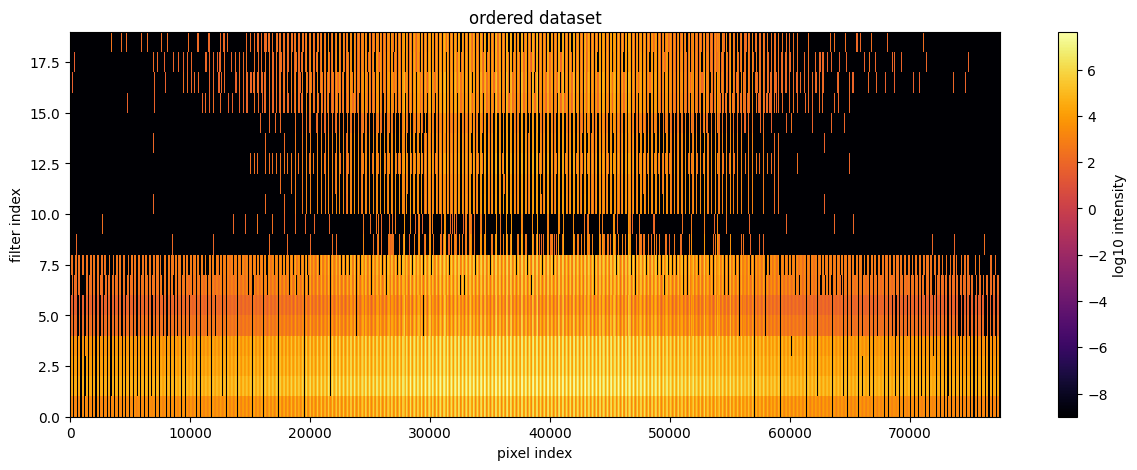

In [15]:


# print the resulting elongation
print("resulting elongation: ", final_elongation)

# print the intermediate elongations for different metrics + scales
estimator_list, scale_list, elongation_list = seq.return_elongation_of_weighted_products_all_metrics_and_scales()

print("intermediate elongations for the different metrics and scales:")
for i in range(len(estimator_list)):
    print("metric=%s, scale=%s, elongation: %s" % (estimator_list[i], 
                                                   scale_list[i], 
                                                   np.round(elongation_list[i], 2)))
    
# plot the ordered dataset
data_reordered = log_data[final_sequence, :]

plt.figure(1, figsize=(15, 5))
plt.title("ordered dataset")
plt.pcolormesh(data_reordered, cmap="inferno")
plt.colorbar(label="log10 intensity")


plt.xlabel("pixel index")
plt.ylabel("filter index")

#plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()

The reason you didn't experience the MemoryError before adding the .T (transpose) is due to how the algorithm's distance matrices scale with the number of "objects" being sequenced. The algorithm inherently requires $O(N^2)$ memory to compute all pairwise distances between the $N$ objects.

Here is what's happening based on the shape of your data_2d:

Without .T: data_2d has a shape of 

(19, 77500)
. In this view, there are exactly 19 objects (the spectral slices/filters), and each object is represented by 77,500 data points (pixels). The algorithm only needs to build a tiny 19x19 matrix, which takes almost no memory.
With .T: data_2d has a shape of 

(77500, 19)
. Now there are 77,500 objects (the individual pixels) to sequence, and each has 19 features. The algorithm tries to compute all pairwise distances between these 77,500 items, and allocating a dense 77,500 x 77,500 matrix requires roughly 44.8 GiB of RAM.
How do you want to proceed?
Depending on what you want to achieve with the Sequencer right now, here are the two ways around this limitation:

Option A: Revert the transpose if you want to sequence the 19 slices. If your goal was simply to sequence the 19 wavelengths/filters based on their spatial distributions, we should just remove the .T from data_2d = data.reshape(data.shape[0], -1).T. That will bring the complexity back down to $19 \times 19$.

Option B: Downsample the pixels if you must sequence the 77,500 pixels. If you genuinely want to see how the 77,500 individual spatial pixels cluster/sequence based on their 19-dimensional spectrum, the memory of standard desktops will not allow building the full array. We need to downsample the pixels substantially. For example, taking a random sample of 5000 pixels or selecting a smaller cropped region, so the matrix fits nicely in RAM.

For instance, this code would take every 15th pixel, resulting in just 5,166 pixels (which takes < 500 MB of RAM):

